# Analyse et nettoyage - Prédiction Churn Client

**Objectif du Projet**
Prédire le churn client et identifier les patterns comportementaux menant à la résiliation de compte.

## 1. Importation et Informations Générales

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re 

pd.set_option('display.width', 1000)

df = pd.read_csv('../data/raw/Customer-Churn-Records.csv')
df = df.convert_dtypes()

print('='*60)
print('Informations générales')
print('='*60)

print('-'*60)
print('Informations globales :\n')
print(df.info())

print('-'*60)
print('Informations structurels (variables numeriques):\n')
cols = [col for col in df.select_dtypes(include=['number']).columns 
        if col not in ['RowNumber', 'CustomerId']]
print(df[cols].describe().T[['min', 'mean', '50%', 'max', 'std']].round(2))

print('-'*60)
print('Informations structurels (variables litterales):\n')
cols = [col for col in df.select_dtypes(include=['string']).columns]
for col in cols:
    print(f"{col} : {df[col].nunique()} valeurs uniques")

print('-'*60)
print('Unicité réferentielle :\n')
print(f"RowNumber : {df['RowNumber'].nunique()} valeurs uniques")
print(f"CustomerId : {df['CustomerId'].nunique()} valeurs uniques")

Informations générales
------------------------------------------------------------
Informations globales :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  Int64  
 1   CustomerId          10000 non-null  Int64  
 2   Surname             10000 non-null  string 
 3   CreditScore         10000 non-null  Int64  
 4   Geography           10000 non-null  string 
 5   Gender              10000 non-null  string 
 6   Age                 10000 non-null  Int64  
 7   Tenure              10000 non-null  Int64  
 8   Balance             10000 non-null  Float64
 9   NumOfProducts       10000 non-null  Int64  
 10  HasCrCard           10000 non-null  Int64  
 11  IsActiveMember      10000 non-null  Int64  
 12  EstimatedSalary     10000 non-null  Float64
 13  Exited              10000 non-null  Int64  

**Observations**
  * Dataset : 10,000 clients avec 18 variables
  * Aucune valeur manquante détectée (0 NA)
  * Types de données bien définis (Int64, Float64, string)
  * Identifiants uniques : RowNumber et CustomerId (10,000 valeurs uniques chacun)

**Résultats Clés**
  * Variables numériques importantes :
    * CreditScore : [350-850], moyenne 650.53 (distribution normale attendue)
    * Age : [18-92 ans], moyenne 38.92 ans
    * Balance : médiane à 97,198€ (forte variance : std=62,397€)
    * NumOfProducts : [1-4], moyenne 1.53, produits 1 et 2 majoritaires
    * Tenure : [0-10 ans], moyenne 5 ans d'ancienneté
    * Taux de churn : 20% (variable Exited)
    * Taux de plaintes : 20% (variable Complain)
    * Score de satisfaction : [1-5], moyenne 3/5.

  * Variables catégorielles :
    * Geography : 3 pays
    * Gender : 2 catégories
    * Card Type : 4 types de carte
    * Surname : 2,932 noms uniques (pas exploitable pour ML)

**Actions**
  * Conversion automatique des types avec convert_dtypes()
  * Identification des variables à supprimer : RowNumber, CustomerId, Surname

## 2. Valeurs manquantes

In [27]:
print('-'*60)
print("Valeurs manquantes :\n")
print(df.isna().sum())

print('-'*60)
print("\nChaînes vides :\n")
print((df == "").sum())

------------------------------------------------------------
Valeurs manquantes :

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64
------------------------------------------------------------

Chaînes vides :

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type

**Observations**
  * 0 valeur manquante (NA)
  * 0 chaîne vide ("")

**Résultat**
  * Dataset complet, pas de traitement d'imputation nécessaire

## 3. Normalisation des noms de colonnes

In [36]:
for col in df.columns:
    parts = re.findall(r'[A-Z][a-z]*', col.replace(" ", ""))
    new_name = "_".join(p.lower() for p in parts)    
    df = df.rename(columns={col: new_name})

print(df.columns)

Index(['row_number', 'customer_id', 'surname', 'credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'exited', 'complain', 'satisfaction_score', 'card_type', 'point_earned'], dtype='object')


**Action**
Conversion en snake_case pour standardisation :
'CreditScore' -> 'credit_score'
'HasCrCard' -> 'has_cr_card'

**Résultat**
  * Noms de colonnes uniformisés
  * Meilleure lisibilité et compatibilité avec les conventions Python

## 3. Distributions

### 3.1 Variables discrètes

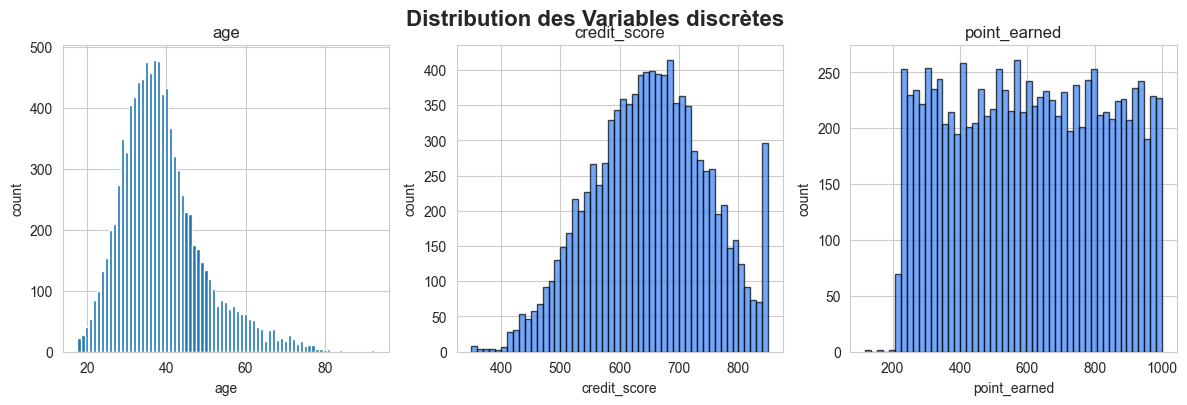

In [29]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 10
blue_color = '#3b82f6'

var_discrete = [
    'age', 'credit_score', 'point_earned'
]

# Créer la figure
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten() 

# Pour chaque variable
for idx, var in enumerate(var_discrete):
    if var == 'credit_score' or  var == 'point_earned':
        axes[idx].hist(df[var], bins=50,color=blue_color, edgecolor='black', alpha=0.7)
        axes[idx].set_title(var)
        axes[idx].set_xlabel(var)
        axes[idx].set_ylabel("count")
    else:   
        count = df[var].value_counts()
        axes[idx].bar(count.index, count.values)
        axes[idx].set_title(var)
        axes[idx].set_xlabel(var)
        axes[idx].set_ylabel("count")

    
# Ajustement layout
plt.tight_layout()
plt.suptitle('Distribution des Variables discrètes\n', 
             fontsize=16, fontweight='bold', y=1.002)

plt.show()

**Observations**
1. Age
    * Distribution quasi-normale avec légère asymétrie droite
    * Pic principal : 35-45 ans (concentration maximale ~480 clients)
    * Queue longue vers les âges élevés (jusqu'à ~90 ans)
    * Minimum : 18 ans (âge légal)
2. credit_score
    * Distribution normale parfaite (courbe de Gauss)
    * Moyenne : ~650 (centre de la distribution)
    * Pic : 600-700 avec ~400 clients
    * Plafonnement du score de crédit à 800 induit un nombre de client avec ce score élevé
3. point_earned
    * Distribution quasi-uniforme (flat distribution)
    * Variation minimale entre bins (~200-250 clients par tranche)
    * Peu de client avec point_earned < 220
  
**Actions à réaliser**
1. Age : Segmentation
    * Young adults (18-30 ans) : ~15% - Début de carrière, forte mobilité / offres compétitives
    * Middle age (30-50 ans) : ~60% - Cœur de cible, revenus stables
    * Seniors (50+ ans) : ~25% - Patrimoine élevé, risque de churn pour retraite/décès
2. Score de credit : Segmentation
    * Poor (350-579) : ~10% - Haut risque, possibles refus de crédit
    * Fair (580-669) : ~35% - Risque moyen, taux d'intérêt élevés
    * Good (670-739) : ~30% - Bon profil, conditions standards       
    * Very Good/Excellent (740-850) : ~25% - Profil premium, offres préférentielles 
3. Points gagnés : Investigation
    * Distribution plate suggère que les points sont attribués de manière uniforme (possiblement en fonction de l'ancienneté ou du volume de transactions)
    * Pas de segmentation naturelle apparente
    * Système de récompense efficace ? : Distribution uniforme suggère peu de différenciation

### 3.2 Variables continues

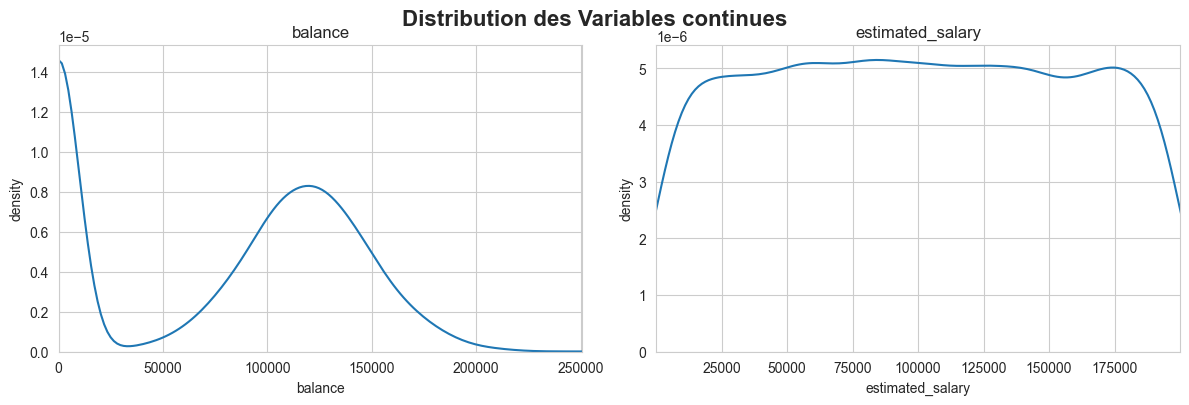

In [30]:
var_continue = [
    'balance', 'estimated_salary'
]

# Créer la figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten() 

# Pour chaque variable
for idx, var in enumerate(var_continue):
    sns.kdeplot(df[var], ax=axes[idx])
    axes[idx].set_title(var)
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel("density")
    axes[idx].set_xlim(df[var].min(), df[var].max())

# Ajustement layout
plt.tight_layout()
plt.suptitle('Distribution des Variables continues\n', 
             fontsize=16, fontweight='bold', y=1.002)

plt.show()

**Observations**
1. Balance
    * Premier pic massif à 0€ (density ~1.4e-5)
    * Creux profond entre 0€ et 50,000€
    * Second pic large centré sur ~120,000€ (density ~0.8e-5)
    * Queue droite s'étendant jusqu'à 250,000€
    * Asymétrie droite (right-skewed)
2. Estimated_salary
    * Forme générale : plateau presque parfait
    * Chute <~12K et >~ 180K
    
**Actions à réaliser**
1. Balance : Investigation / Segmentation (Zero, Low, Medium, High)
    * Balance = 0 = Risque de churn élevé ?
    * Balance élevée (>150K) = Risque de churn faible ?
    * Zone intermédiaire (50K-100K) = Comportement à clarifier
2. Salaire estimé : Investigation
    * Les salaires réels suivent généralement une distribution log-normale
    * Données synthétiques ou simulées ?
    * Salaires regroupés en tranches égales ?

### 3.2 Variables catégorielle / ordinales

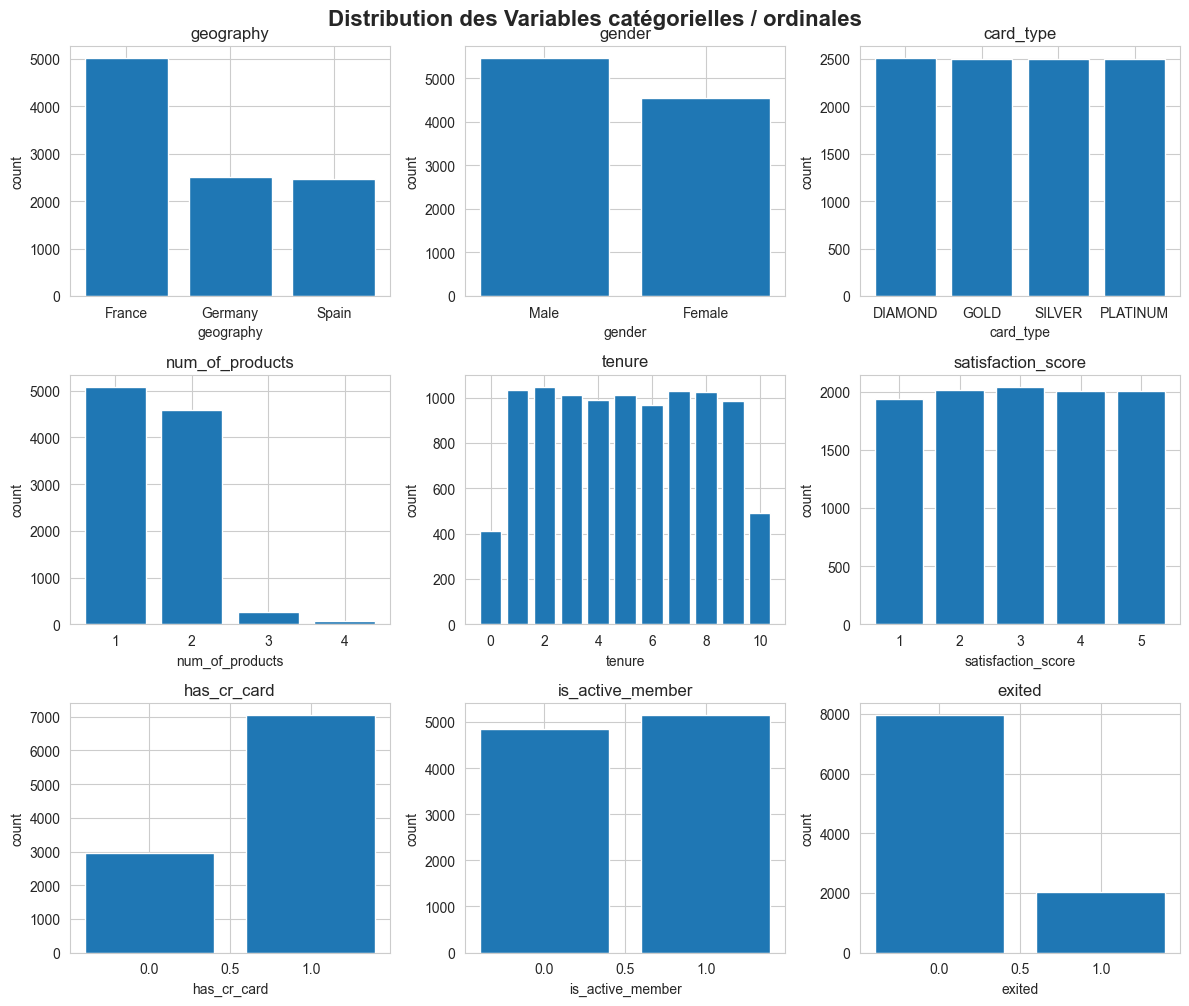

In [31]:
var_category = [
    'geography', 'gender', 'card_type', 'num_of_products', 'tenure', 'satisfaction_score', 'has_cr_card', 'is_active_member', 'exited'
]

# Créer la figure
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten() 

# Pour chaque variable
for idx, var in enumerate(var_category):
    count = df[var].value_counts()
    axes[idx].bar(count.index, count.values)
    axes[idx].set_title(var)
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel("count")


# Ajustement layout
plt.tight_layout()
plt.suptitle('Distribution des Variables catégorielles / ordinales\n', 
             fontsize=16, fontweight='bold', y=1.002)

plt.show()

**Observations**
1. geographie
  * France : ~5,000 clients (52%) - MAJORITÉ
  * Germany : ~2,500 clients (26%)
  * Spain : ~2,500 clients (26%)
2. gender
  * Male : ~5,400 clients (55%)
  * Female : ~4,600 clients (45%)
  * Légère sur-représentation masculine
3. card_type
  * Distribution Uniforme
  * Uniformité suspecte (comme estimated_salary) = Possibles données artificielles
4. num_of_products
  * 98% des clients ont produit 1 ou 2
  * produits 3-4 = outliers extrêmes
5. tenure
  * Plateau entre 1-10 ans (~1,000 clients par année)
  * Légère baisse à 0 ans (~400 nouveaux clients)
  * Légère baisse à 10 ans (~500 clients très anciens)
6. Score de satisfaction
  * Distribution uniforme => suspect
7. has_cr_card
  * Oui : ~7,000 clients (70%)
  * Non : ~3,000 clients (30%)
8. is_active_member
  * Actif : ~5,000 clients (50%)
  * Inactif : ~5,000 clients (50%)

**Actions à réaliser**
1. geographie
  * Vérifier le taux churn varie par pays
2. gender
  * Peu de biais de genre attendu : Vérifier le taux de churn par genre
3. card_type
  * Variable à faible utilité pour la prédiction du churn
4. num_of_products
  * Vérifier si les prodcorrélé au churn
  * Vérifier si produits 3 et 4 sont fortement corrélés au churn
5. tenure
  * Pas de signe de churn lié avec l'ancienneté
6. Score de satisfaction
  * Distribution uniforme = données artificielles
  * Capacité de prédiction douteuse
7. has_cr_card
  * Taux de détention élevé
  * Variable potentiellement discriminante
8. is_active_member
  * 50% de clients inactif est énorme ! => Signe d'alerte si fortement corrélé avec le churn

## 4. Détection des incohérences

### 4.1 Vérification des Limites (Boundaries)

In [32]:
age_invalid = (df['age'] < 18) | (df['age'] > 100)

tenure_invalid = (df['tenure'] < 0) | (df['tenure'] > 50)

credit_score_invalid = (df['credit_score'] < 300) | (df['credit_score'] > 850)

balance_invalid = df['balance'] < 0

salary_invalid = (df['estimated_salary'] < 0) | (df['estimated_salary'] > 1000000)

products_invalid = (df['num_of_products'] < 0) | (df['num_of_products'] > 10)

points_invalid = (df['point_earned'] < 0) | (df['point_earned'] > 1000)

satisfaction_invalid = (df['satisfaction_score'] < 1) | (df['satisfaction_score'] > 5)

binary_invalid = (
    (~df['has_cr_card'].isin([0, 1])) |
    (~df['is_active_member'].isin([0, 1])) |
    (~df['exited'].isin([0, 1])) |
    (~df['complain'].isin([0, 1]))
)

print('-'*60)
print(f"Nombre d'ages invalides : {age_invalid.sum()}")
print(f"Nombre d'années d'ancienneté invalides : {tenure_invalid.sum()}")
print(f"Nombre de score de crédit invalides : {credit_score_invalid.sum()}")
print(f"Nombre de balances invalides : {balance_invalid.sum()}")
print(f"Nombre de produits invalides : {products_invalid.sum()}")
print(f"Nombre de points gagnés invalides : {points_invalid.sum()}")
print(f"Nombre de score de satisfaction invalides : {satisfaction_invalid.sum()}")
print(f"Nombre de variables binaires invalides : {binary_invalid.sum()}")

------------------------------------------------------------
Nombre d'ages invalides : 0
Nombre d'années d'ancienneté invalides : 0
Nombre de score de crédit invalides : 0
Nombre de balances invalides : 0
Nombre de produits invalides : 0
Nombre de points gagnés invalides : 0
Nombre de score de satisfaction invalides : 0
Nombre de variables binaires invalides : 0


**Observations**
Tests effectués sur 8 dimensions :
  * Âge [18-100 ans]
  * Ancienneté [0-50 ans]
  * Score de crédit [300-850]
  * Balance ≥ 0
  * Nombre de produits [0-10]
  * Points gagnés [0-1000]
  * Score de satisfaction [1-5]
  * Variables binaires {0,1}

**Résultat**
0 incohérence détectée sur les limites individuelles

### 4.2 Incohérences Entre Variables

In [37]:
print('-'*60)
print('Age minimum requis pour ouvrir un compte bancaire par pays :')
print(df.groupby('geography').agg({'age' : 'min'})['age'])

print('-'*60)
print('Incohérences :')
print(f"Clients avec ancienneté suspecte (compte ouvert avant 18ans): {(df['age'] - df['tenure'] < 18).sum()} ({(df['age'] - df['tenure'] < 18).sum()/ len(df)}%)")

nb_clients = (
    df.groupby('customer_id')
      .size()
      .gt(1)
      .sum()
)

print("Clients avec plusieurs produits :", nb_clients)

------------------------------------------------------------
Age minimum requis pour ouvrir un compte bancaire par pays :
geography
France     18
Germany    18
Spain      18
Name: age, dtype: Int64
------------------------------------------------------------
Incohérences :
Clients avec ancienneté suspecte (compte ouvert avant 18ans): 322 (0.0322%)
Clients avec plusieurs produits : 0


**Observations Critiques**
1. Clients avec ancienneté suspecte : 322 cas (3.22%)
  * Condition : age - tenure < 18
  * Problème : Compte bancaire ouvert avant l'âge légal de 18 ans
  * Exemple : Client de 25 ans avec 10 ans d'ancienneté = compte ouvert à 15 ans
  * Explication métier : Un parent/tuteur peut ouvrir un compte bancaire à un mineur en son nom
  
2. Vérification du nombre de produits :
  * Clients avec > 1 produits : 0
  
**Action**
1. Vérification de l'âge légal minimum par pays :
  * France = 18
  * Germany = 18
  * Spain = 18
2. Identification des lignes auxquelles ajouter un flag : 'open_account_bf_major' = True

## 5. Vérifications finales et sauvegarde

In [38]:
print("="*80)
print("Vérification avant sauvegarde")
print("="*80)

print(f"Dimensions du dataframe : {df.shape}")
print(f"Valeurs manquantes : {df.isna().sum().sum()}")
print("\nTypes des colonnes :") 
print(df.dtypes)

df.to_csv('../data/preprocessed/01_churn_records.csv', index=False)
print(f"\ncsv sauvegardé à l'emplacement '../data/preprocessed/01_churn_records.csv'")

Vérification avant sauvegarde
Dimensions du dataframe : (10000, 18)
Valeurs manquantes : 0

Types des colonnes :
row_number                     Int64
customer_id                    Int64
surname               string[python]
credit_score                   Int64
geography             string[python]
gender                string[python]
age                            Int64
tenure                         Int64
balance                      Float64
num_of_products                Int64
has_cr_card                    Int64
is_active_member               Int64
estimated_salary             Float64
exited                         Int64
complain                       Int64
satisfaction_score             Int64
card_type             string[python]
point_earned                   Int64
dtype: object

csv sauvegardé à l'emplacement '../data/preprocessed/01_churn_records.csv'


**Dimensions** : 10000 lignes × 18 colonnes

**Qualité des données** :
- 0 valeur manquante
- 0 incohérence de limites
- 0 incohérence inter-variables
- Types de données corrects (Int64, Float64, string)

**Variables conservées** :

- Numériques (12) : credit_score, age, tenure, balance, num_of_products, 
                  has_cr_card, is_active_member, estimated_salary, 
                  exited, complain, satisfaction_score, point_earned

- Catégorielles (4) : surname, geography, gender, card_type

- Identifiants (2) : row_number, customer_id

**Actions** 
Sauvegardé le fichier '../data/preprocessed/01_churn_records.csv' avec les noms de colonnes renommés.

**Synthèse**
1. Ajouter le flag 'open_account_bf_major' = True pour les clients ayant ouvert leurs compte avant 18ans
2. A Segmenter :
    * Age ('Young', 'Adult', 'Middle-aged', 'Senior')
    * Score de crédit ('Poor', 'Fair', 'Good', 'Excellent')
    * Balance ('Zero', 'Low', 'Medium', 'High')
4. A Supprimer
    * row_number
    * customer_id
    * surname    
5. Variables seules peu discriminantes
    * estimated_salary : données artificielles ?
    * point_earned : données uniformes
    * card_type : données artificielles ?
    * tenure : données uniformes
    * satisfaction_score : données uniformes
6. Variables seules discriminantes
    * num_of_products
    * age
    * balance
    * is_active_member